In [1]:
import cv2
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import os

# --- 1. Dino v2モデルのロード ---
def load_dino_v2_model(model_name='dinov2_vits14'):
    """Dino v2モデルをロードする"""
    try:
        # Facebook Researchのリポジトリから直接ロード
        model = torch.hub.load('facebookresearch/dinov2', model_name)
        model.eval()
        if torch.cuda.is_available():
            model = model.cuda()
        print(f"{model_name} loaded successfully.")
        return model
    except Exception as e:
        print(f"Error loading Dino v2 model: {e}")
        print("Please ensure you have an internet connection and the correct model name.")
        return None

# --- 2. 画像の前処理 ---
def preprocess_image(image_pil, image_size=224):
    """Dino v2モデルへの入力用に画像を前処理する"""
    transform = T.Compose([
        T.Resize(image_size, interpolation=T.InterpolationMode.BICUBIC),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
    return transform(image_pil).unsqueeze(0) # バッチ次元を追加

# --- 3. 特徴抽出 ---
def extract_features(model, frame_pil):
    """画像からDino v2特徴を抽出する"""
    if model is None:
        return None
    img_tensor = preprocess_image(frame_pil)
    if torch.cuda.is_available():
        img_tensor = img_tensor.cuda()

    with torch.no_grad():
        features = model(img_tensor) # パッチトークンではなくCLSトークン（または平均プーリング）を利用
        # Dino v2はCLSトークンを明示的には返さないため、
        # features_dict = model.forward_features(img_tensor)
        # features = features_dict['x_norm_clstoken'] # または他の適切な特徴
        # または最後のレイヤーのパッチトークンを平均する
        # features = model.get_intermediate_layers(img_tensor, n=1, return_class_token=True)[0][1] # CLSトークン
        features = model.forward_features(img_tensor)['x_norm_patchtokens'].mean(dim=1) # パッチトークンの平均
    return features.cpu().numpy().flatten()

# --- 4. 動画からフレームを抽出し、特徴を計算 ---
def process_video(video_path, model, batch_size=32, frame_skip=1):
    """動画を処理し、各フレームの特徴を抽出する"""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return None, None

    frames_features = []
    frame_indices = []
    frame_count = 0
    processed_frame_count = 0

    batch_frames_pil = []

    while True:
        ret, frame_cv2 = cap.read()
        if not ret:
            break

        if frame_count % frame_skip == 0:
            frame_pil = Image.fromarray(cv2.cvtColor(frame_cv2, cv2.COLOR_BGR2RGB))
            batch_frames_pil.append(frame_pil)
            frame_indices.append(frame_count)

            if len(batch_frames_pil) == batch_size:
                batch_features = []
                for f_pil in batch_frames_pil:
                    features = extract_features(model, f_pil)
                    if features is not None:
                        batch_features.append(features)
                if batch_features:
                    frames_features.extend(batch_features)
                batch_frames_pil = []
                processed_frame_count += len(batch_features)
                print(f"Processed {processed_frame_count} frames...")


        frame_count += 1

    # 残りのフレームを処理
    if batch_frames_pil:
        batch_features = []
        for f_pil in batch_frames_pil:
            features = extract_features(model, f_pil)
            if features is not None:
                batch_features.append(features)
        if batch_features:
            frames_features.extend(batch_features)
        processed_frame_count += len(batch_features)
        print(f"Processed {processed_frame_count} frames...")


    cap.release()
    if not frames_features:
        print("No features extracted. Check video or model.")
        return None, None
    return np.array(frames_features), frame_indices

# --- 5. シーン境界検出 (コサイン類似度と閾値ベース) ---
def detect_scenes_by_similarity(features, threshold=0.85):
    """隣接フレーム間のコサイン類似度に基づいてシーン境界を検出する"""
    if features is None or len(features) < 2:
        return [0] # 少なくとも1つのシーン

    similarities = []
    for i in range(len(features) - 1):
        sim = cosine_similarity(features[i].reshape(1, -1), features[i+1].reshape(1, -1))[0, 0]
        similarities.append(sim)

    scene_boundaries = [0] # 最初のフレームは常にシーンの開始
    for i, sim in enumerate(similarities):
        if sim < threshold:
            scene_boundaries.append(i + 1) # 境界は次のフレームのインデックス
    print(f"Found {len(scene_boundaries)} potential scene starts using similarity threshold.")
    return scene_boundaries

# --- 5. シーン境界検出 (K-meansクラスタリングベース) ---
def detect_scenes_by_clustering(features, num_scenes_approx=None, min_scene_length=10):
    """フレーム特徴のK-meansクラスタリングに基づいてシーン境界を検出する"""
    if features is None or len(features) == 0:
        return [0]

    if num_scenes_approx is None:
        # ヒューリスティック: フレーム数の平方根の半分程度をシーン数とする (調整が必要)
        num_scenes_approx = max(2, int(np.sqrt(len(features)) / 2))

    if len(features) < num_scenes_approx:
        print(f"Warning: Number of frames ({len(features)}) is less than num_scenes_approx ({num_scenes_approx}). Adjusting num_scenes to {len(features)}.")
        num_scenes_approx = len(features)
        if num_scenes_approx == 0: return [0]


    print(f"Attempting clustering with n_clusters={num_scenes_approx}")
    try:
        kmeans = KMeans(n_clusters=num_scenes_approx, random_state=0, n_init='auto')
        cluster_labels = kmeans.fit_predict(features)
    except ValueError as e:
        print(f"Error during KMeans fitting: {e}. This might happen if n_samples < n_clusters.")
        # フォールバックとして、各フレームを個別のシーン（または単一シーン）として扱う
        if len(features) > 0:
            return list(range(len(features)))
        else:
            return [0]


    scene_boundaries = [0]
    current_scene_label = cluster_labels[0]
    last_boundary = 0
    for i in range(1, len(cluster_labels)):
        if cluster_labels[i] != current_scene_label:
            # 新しいシーンが短すぎる場合はマージを検討（ここでは単純な境界検出）
            if (i - last_boundary) >= min_scene_length or not scene_boundaries:
                scene_boundaries.append(i)
                current_scene_label = cluster_labels[i]
                last_boundary = i
            # else:
                # print(f"Skipping short scene candidate at frame {i}")


    # 最後のシーンが短すぎる場合、前のシーンとマージ (より頑健なロジックが必要)
    if len(scene_boundaries) > 1 and (len(features) - scene_boundaries[-1]) < min_scene_length:
         # print(f"Last scene is too short, merging with previous. Popping boundary: {scene_boundaries[-1]}")
         if len(scene_boundaries) > 1 : scene_boundaries.pop()


    # シーン境界が全くない場合（全フレームが同一クラスタ）、最初のフレームのみを境界とする
    if not scene_boundaries:
        scene_boundaries = [0]

    print(f"Found {len(scene_boundaries)} potential scene starts using clustering.")
    return scene_boundaries


# --- 6. フレームをシーンに割り当て、結果を保存 ---
def assign_frames_to_scenes_and_save(video_path, frame_indices_original, scene_boundaries_indices, output_dir="scene_outputs"):
    """検出されたシーンに基づいてフレームを分類し、各シーンのフレームを保存する"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path} for saving frames.")
        return

    scene_info = [] # (scene_id, start_frame_original, end_frame_original)

    num_scenes = len(scene_boundaries_indices)
    current_frame_idx_original = 0 # 動画全体のフレームカウンタ
    processed_feature_idx = 0 # 特徴抽出されたフレームのインデックス

    for i in range(num_scenes):
        scene_start_feature_idx = scene_boundaries_indices[i]
        scene_end_feature_idx = scene_boundaries_indices[i+1] -1 if (i + 1) < num_scenes else len(frame_indices_original) - 1

        # 特徴抽出時のインデックスを元の動画のフレームインデックスにマッピング
        scene_start_original_frame_idx = frame_indices_original[scene_start_feature_idx]
        scene_end_original_frame_idx = frame_indices_original[scene_end_feature_idx]

        scene_id = i + 1
        scene_info.append((scene_id, scene_start_original_frame_idx, scene_end_original_frame_idx))
        print(f"Scene {scene_id}: Original frames {scene_start_original_frame_idx} to {scene_end_original_frame_idx}")

        scene_frame_dir = os.path.join(output_dir, f"scene_{scene_id:03d}")
        if not os.path.exists(scene_frame_dir):
            os.makedirs(scene_frame_dir)

        # このシーンに属するフレームを保存
        # 動画を再度読み込み、該当範囲のフレームを保存 (効率は悪いがシンプル)
        # より効率的な方法: 最初に全フレームを一時保存するか、フレームインデックスで直接アクセス

    # フレーム保存のロジック (例: 動画を再度シークして保存)
    # この部分は、フレームを効率的に取得する方法に依存します。
    # 下記は単純な再読み込みですが、大規模動画では非効率です。
    current_frame_idx_video = 0
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0) # 動画の先頭に戻る
    scene_write_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if scene_write_idx < len(scene_info):
            s_id, s_start, s_end = scene_info[scene_write_idx]
            if s_start <= current_frame_idx_video <= s_end:
                # 現在のフレームが現在の書き込み対象シーン内にある
                frame_filename = os.path.join(output_dir, f"scene_{s_id:03d}", f"frame_{current_frame_idx_video:06d}.jpg")
                cv2.imwrite(frame_filename, frame)
            elif current_frame_idx_video > s_end:
                # 次のシーンに移る
                scene_write_idx += 1
                if scene_write_idx < len(scene_info):
                    s_id_next, s_start_next, _ = scene_info[scene_write_idx]
                    if s_start_next <= current_frame_idx_video <= scene_info[scene_write_idx][2]: # 新しいシーンの範囲内か確認
                         frame_filename = os.path.join(output_dir, f"scene_{s_id_next:03d}", f"frame_{current_frame_idx_video:06d}.jpg")
                         cv2.imwrite(frame_filename, frame)


        current_frame_idx_video +=1

    cap.release()
    print(f"Frames for {num_scenes} scenes saved in '{output_dir}'.")
    return scene_info

In [2]:
# --- メイン処理 ---
VIDEO_PATH = "/content/3974-176000794_tiny.mp4"  # あなたの動画ファイルパスに置き換えてください
OUTPUT_DIR = "video_scene_output"
FRAME_SKIP = 5  # Nフレームごとに処理 (1なら全フレーム)
BATCH_SIZE_FEATURES = 16 # 特徴抽出時のバッチサイズ
# DETECTION_METHOD = "similarity" # "similarity" or "clustering"
DETECTION_METHOD = "clustering"

# シーン検出のパラメータ (手法によって調整)
SIMILARITY_THRESHOLD = 0.75 # 値が低いほど多くのシーンが検出される (similarity法用)
NUM_SCENES_APPROX = None # Noneの場合、クラスタリングで自動推定 (clustering法用、適宜数値を指定)
MIN_SCENE_LENGTH_FRAMES = 15 # 最小のシーン長 (特徴抽出後のフレーム数)

if not os.path.exists(VIDEO_PATH):
    print(f"Error: Video file not found at {VIDEO_PATH}")
    exit()

# 1. Dino v2モデルのロード
print("Loading Dino v2 model...")
dino_model = load_dino_v2_model()
if dino_model is None:
    exit()

# 2. 動画からフレームを抽出し、特徴を計算
print(f"Processing video: {VIDEO_PATH}...")
frame_features, original_frame_indices = process_video(VIDEO_PATH, dino_model, batch_size=BATCH_SIZE_FEATURES, frame_skip=FRAME_SKIP)

if frame_features is None or not original_frame_indices:
    print("Feature extraction failed.")
    exit()

print(f"Extracted {len(frame_features)} features from {len(original_frame_indices)} sampled frames.")

# 3. シーン境界検出
print(f"Detecting scene boundaries using {DETECTION_METHOD} method...")
if DETECTION_METHOD == "similarity":
    scene_boundary_indices_in_features = detect_scenes_by_similarity(frame_features, threshold=SIMILARITY_THRESHOLD)
elif DETECTION_METHOD == "clustering":
    scene_boundary_indices_in_features = detect_scenes_by_clustering(frame_features, num_scenes_approx=NUM_SCENES_APPROX, min_scene_length=MIN_SCENE_LENGTH_FRAMES)
else:
    print(f"Error: Unknown detection method {DETECTION_METHOD}")
    exit()

if not scene_boundary_indices_in_features :
    print("No scene boundaries detected.")
    # 少なくともビデオ全体を1つのシーンとして扱う
    scene_boundary_indices_in_features = [0]


print(f"Scene boundary indices (in terms of processed frames): {scene_boundary_indices_in_features}")


# 4. フレームをシーンに割り当て、結果を保存
print("Assigning frames to scenes and saving...")
scene_information = assign_frames_to_scenes_and_save(VIDEO_PATH, original_frame_indices, scene_boundary_indices_in_features, output_dir=OUTPUT_DIR)

if scene_information:
    print("\nScene Information (Original Frame Numbers):")
    for scene_id, start_frame, end_frame in scene_information:
        print(f"  Scene {scene_id}: Frames {start_frame} - {end_frame}")
print("Processing complete.")

Loading Dino v2 model...


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth
100%|██████████| 84.2M/84.2M [00:00<00:00, 252MB/s]


dinov2_vits14 loaded successfully.
Processing video: /content/3974-176000794_tiny.mp4...
Processed 16 frames...
Processed 32 frames...
Processed 48 frames...
Processed 64 frames...
Processed 80 frames...
Processed 96 frames...
Processed 112 frames...
Processed 125 frames...
Extracted 125 features from 125 sampled frames.
Detecting scene boundaries using clustering method...
Attempting clustering with n_clusters=5
Found 5 potential scene starts using clustering.
Scene boundary indices (in terms of processed frames): [0, 42, 59, 74, 106]
Assigning frames to scenes and saving...
Scene 1: Original frames 0 to 205
Scene 2: Original frames 210 to 290
Scene 3: Original frames 295 to 365
Scene 4: Original frames 370 to 525
Scene 5: Original frames 530 to 620
Frames for 5 scenes saved in 'video_scene_output'.

Scene Information (Original Frame Numbers):
  Scene 1: Frames 0 - 205
  Scene 2: Frames 210 - 290
  Scene 3: Frames 295 - 365
  Scene 4: Frames 370 - 525
  Scene 5: Frames 530 - 620
Proce

In [3]:
# Jupyter Notebookの最初にこれを記述しておくと、matplotlibのプロットがインラインで表示されます
%matplotlib inline

import cv2
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display, Image as IPImage # フレーム画像表示用 (オプション)

# --- 1. Dino v2モデルのロード ---
def load_dino_v2_model(model_name='dinov2_vits14'):
    """Dino v2モデルをロードする"""
    try:
        model = torch.hub.load('facebookresearch/dinov2', model_name)
        model.eval()
        if torch.cuda.is_available():
            model = model.cuda()
        print(f"{model_name} loaded successfully.")
        return model
    except Exception as e:
        print(f"Error loading Dino v2 model: {e}")
        print("Please ensure you have an internet connection and the correct model name.")
        return None

# --- 2. 画像の前処理 ---
def preprocess_image(image_pil, image_size=224):
    """Dino v2モデルへの入力用に画像を前処理する"""
    transform = T.Compose([
        T.Resize(image_size, interpolation=T.InterpolationMode.BICUBIC),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])
    return transform(image_pil).unsqueeze(0)

# --- 3. 特徴抽出 ---
def extract_features(model, frame_pil):
    """画像からDino v2特徴を抽出する"""
    if model is None:
        return None
    img_tensor = preprocess_image(frame_pil)
    if torch.cuda.is_available():
        img_tensor = img_tensor.cuda()

    with torch.no_grad():
        # CLSトークンを使用する場合 (モデルによってパスが異なる可能性あり)
        # features = model.get_intermediate_layers(img_tensor, n=1, return_class_token=True)[0][:, 0] # ViTの場合
        # パッチトークンの平均を使用する場合
        features = model.forward_features(img_tensor)['x_norm_patchtokens'].mean(dim=1)
    return features.cpu().numpy().flatten()

# --- 4. 動画からフレームを抽出し、特徴を計算 ---
def process_video(video_path, model, batch_size=32, frame_skip=1):
    """動画を処理し、各フレームの特徴と元のフレームインデックスを抽出する"""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return None, None, None

    frames_features = []
    original_frame_indices = [] # frame_skipを考慮した元の動画のフレームインデックス
    extracted_frames_pil = [] # 可視化用にPILイメージも保存 (オプション)

    frame_count = 0
    processed_feature_count = 0

    batch_frames_pil_for_feature = []
    batch_original_indices = []

    while True:
        ret, frame_cv2 = cap.read()
        if not ret:
            break

        if frame_count % frame_skip == 0:
            frame_pil = Image.fromarray(cv2.cvtColor(frame_cv2, cv2.COLOR_BGR2RGB))
            batch_frames_pil_for_feature.append(frame_pil)
            batch_original_indices.append(frame_count)
            extracted_frames_pil.append(frame_pil) # オプション: 後で代表フレーム表示用

            if len(batch_frames_pil_for_feature) == batch_size:
                batch_features = []
                for f_pil in batch_frames_pil_for_feature:
                    features = extract_features(model, f_pil)
                    if features is not None:
                        batch_features.append(features)

                if batch_features:
                    frames_features.extend(batch_features)
                    original_frame_indices.extend(batch_original_indices)
                    processed_feature_count += len(batch_features)
                    print(f"Processed features for {processed_feature_count} frames...")

                batch_frames_pil_for_feature = []
                batch_original_indices = []

        frame_count += 1

    # 残りのフレームを処理
    if batch_frames_pil_for_feature:
        batch_features = []
        for f_pil in batch_frames_pil_for_feature:
            features = extract_features(model, f_pil)
            if features is not None:
                batch_features.append(features)
        if batch_features:
            frames_features.extend(batch_features)
            original_frame_indices.extend(batch_original_indices)
            processed_feature_count += len(batch_features)
            print(f"Processed features for {processed_feature_count} frames (final batch)...")

    cap.release()
    if not frames_features:
        print("No features extracted. Check video or model.")
        return None, None, None

    total_original_frames = frame_count
    print(f"Total original frames in video: {total_original_frames}")
    return np.array(frames_features), original_frame_indices, extracted_frames_pil, total_original_frames

# --- 5. シーン境界検出 (コサイン類似度と閾値ベース) ---
def detect_scenes_by_similarity(features, threshold=0.85):
    if features is None or len(features) < 2:
        return [0]
    similarities = [cosine_similarity(features[i].reshape(1, -1), features[i+1].reshape(1, -1))[0, 0] for i in range(len(features) - 1)]
    scene_boundaries = [0] + [i + 1 for i, sim in enumerate(similarities) if sim < threshold]
    print(f"Found {len(scene_boundaries)} potential scene starts using similarity threshold.")
    return scene_boundaries

# --- 5. シーン境界検出 (K-meansクラスタリングベース) ---
def detect_scenes_by_clustering(features, num_scenes_approx=None, min_scene_length_features=5):
    if features is None or len(features) == 0:
        return [0]
    n_samples = len(features)
    if num_scenes_approx is None:
        num_scenes_approx = max(2, int(np.sqrt(n_samples) / 2))

    num_clusters = min(num_scenes_approx, n_samples) # クラスタ数はサンプル数以下
    if num_clusters == 0: return [0]
    if num_clusters == 1 and n_samples > 0 : return [0] # 1クラスタなら全編1シーン

    print(f"Attempting clustering with n_clusters={num_clusters}")
    try:
        kmeans = KMeans(n_clusters=num_clusters, random_state=0, n_init='auto')
        cluster_labels = kmeans.fit_predict(features)
    except ValueError as e:
        print(f"Error during KMeans fitting: {e}. Returning single scene.")
        return [0]

    scene_boundaries = [0]
    if n_samples > 0:
        current_scene_label = cluster_labels[0]
        last_boundary_idx = 0
        for i in range(1, n_samples):
            if cluster_labels[i] != current_scene_label:
                if (i - last_boundary_idx) >= min_scene_length_features :
                    scene_boundaries.append(i)
                    current_scene_label = cluster_labels[i]
                    last_boundary_idx = i
                # else:
                    # print(f"Skipping short scene candidate at feature index {i}")

    # 最後のシーンが短すぎる場合の処理 (オプション)
    # if len(scene_boundaries) > 1 and (n_samples - scene_boundaries[-1]) < min_scene_length_features:
    #     if len(scene_boundaries) > 1: scene_boundaries.pop()

    if not scene_boundaries: scene_boundaries = [0] # 念のため
    print(f"Found {len(scene_boundaries)} potential scene starts using clustering.")
    return scene_boundaries

# --- 6. シーン割り当て情報の生成 ---
def generate_scene_assignments(feature_frame_indices, scene_boundary_feature_indices, total_feature_frames):
    """
    各特徴フレームがどのシーンに属するかを割り当てる。
    Args:
        feature_frame_indices (list): 特徴が抽出された元の動画のフレームインデックスのリスト。
        scene_boundary_feature_indices (list): シーン境界の「特徴フレームのインデックス」。
        total_feature_frames (int): 特徴が抽出された総フレーム数。
    Returns:
        list of tuples: [(scene_id, start_original_frame, end_original_frame), ...]
        list of int: 各特徴フレームに対応するシーンIDのリスト。
    """
    scene_info_original_frames = []

    # 特徴フレームごとのシーンIDリストを作成
    feature_frame_scene_labels = np.zeros(total_feature_frames, dtype=int)
    num_scenes = len(scene_boundary_feature_indices)

    for i in range(num_scenes):
        scene_start_feature_idx = scene_boundary_feature_indices[i]
        scene_end_feature_idx = scene_boundary_feature_indices[i+1] - 1 if (i + 1) < num_scenes else total_feature_frames - 1

        current_scene_id = i
        feature_frame_scene_labels[scene_start_feature_idx : scene_end_feature_idx + 1] = current_scene_id

        # 元の動画のフレームインデックスにマッピング
        start_original_frame = feature_frame_indices[scene_start_feature_idx]
        end_original_frame = feature_frame_indices[scene_end_feature_idx]
        scene_info_original_frames.append((current_scene_id, start_original_frame, end_original_frame))

    return scene_info_original_frames, list(feature_frame_scene_labels)


# --- 7. シーン分類結果の可視化 ---
def visualize_scene_timeline(scene_info_original_frames, total_original_video_frames, feature_frame_indices, feature_frame_scene_labels):
    """シーンの区切りをタイムラインプロットで表示する"""

    fig, ax = plt.subplots(figsize=(15, 3)) # 縦の高さを調整

    # 色の準備 (シーンIDごとに異なる色)
    colors = list(mcolors.TABLEAU_COLORS.values()) # Tableauカラーを使用

    # 方法1: 各特徴フレームの位置にシーンIDで色付けしたマーカーをプロット
    # ax.scatter(feature_frame_indices, [0] * len(feature_frame_indices),
    #            c=[colors[label % len(colors)] for label in feature_frame_scene_labels],
    #            marker='|', s=200) # マーカーサイズを大きく

    # 方法2: 各シーンを長方形（バー）で表示
    for scene_id, start_orig_frame, end_orig_frame in scene_info_original_frames:
        color = colors[scene_id % len(colors)]
        # ax.axvspan(start_orig_frame, end_orig_frame + 1, color=color, alpha=0.5, ymin=0, ymax=1) # +1 で終点を含む
        # Rectangleを使う場合
        rect_width = end_orig_frame - start_orig_frame + 1
        rect = plt.Rectangle((start_orig_frame, 0), rect_width, 1,
                             color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)
        # シーンIDを中央に表示
        ax.text(start_orig_frame + rect_width / 2, 0.5, f"{scene_id}",
                color='white' if np.mean(mcolors.to_rgb(color)) < 0.5 else 'black', # 背景色に応じて文字色変更
                ha='center', va='center', fontsize=9, weight='bold')


    ax.set_xlim(0, total_original_video_frames)
    ax.set_ylim(0, 1) # バーの高さに合わせる
    ax.set_xlabel("Original Video Frame Number")
    ax.set_yticks([]) # Y軸の目盛りは不要
    ax.set_title("Video Scene Segmentation Timeline")
    plt.tight_layout()
    plt.show()

    print("\nScene Information (Scene ID, Original Start Frame, Original End Frame):")
    for scene_id, start_frame, end_frame in scene_info_original_frames:
        print(f"  Scene {scene_id}: Frames {start_frame} - {end_frame}")


def display_representative_frames(video_path, scene_info_original_frames, num_frames_per_scene=1, frame_skip_for_display=10):
    """各シーンの代表フレームを表示する (オプション)"""
    print("\nRepresentative frames per scene:")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Could not open video for displaying frames.")
        return

    for scene_id, start_frame, end_frame in scene_info_original_frames:
        print(f"\n--- Scene {scene_id} (Frames {start_frame}-{end_frame}) ---")

        scene_duration = end_frame - start_frame + 1
        if scene_duration <= 0: continue

        # 表示するフレームのインデックスを計算
        # ここではシーンの開始、中間、終了付近から均等に取得
        indices_to_show = []
        if num_frames_per_scene == 1:
            indices_to_show = [start_frame + scene_duration // 2] # 中間フレーム
        elif num_frames_per_scene > 1:
            indices_to_show = np.linspace(start_frame, end_frame, num_frames_per_scene, dtype=int)

        frames_shown_this_scene = 0
        for frame_idx_orig in sorted(list(set(indices_to_show))): # 重複除去してソート
            if frames_shown_this_scene >= num_frames_per_scene:
                break

            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx_orig)
            ret, frame_cv2 = cap.read()
            if ret:
                frame_pil = Image.fromarray(cv2.cvtColor(frame_cv2, cv2.COLOR_BGR2RGB))
                print(f"  Displaying original frame: {frame_idx_orig}")
                display(frame_pil.resize((320, 180))) # サイズ調整して表示
                frames_shown_this_scene +=1
            # else:
                # print(f"Warning: Could not read frame {frame_idx_orig}")
    cap.release()

Loading Dino v2 model...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


dinov2_vits14 loaded successfully.

Processing video: /content/3974-176000794_tiny.mp4...
Processed features for 16 frames...
Processed features for 32 frames...
Processed features for 48 frames...
Processed features for 64 frames...
Processed features for 80 frames...
Processed features for 96 frames...
Processed features for 112 frames...
Processed features for 125 frames (final batch)...
Total original frames in video: 623

Extracted 125 features from 125 sampled frames (every 5 original frames).
Original video has 623 total frames.

Detecting scene boundaries using clustering method...
Attempting clustering with n_clusters=5
Found 5 potential scene starts using clustering.
Scene boundary indices (in terms of processed feature frames): [0, 42, 59, 72, 106]

Visualizing scene timeline...


<ipython-input-3-ecfca71ae89c>:230: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle((start_orig_frame, 0), rect_width, 1,


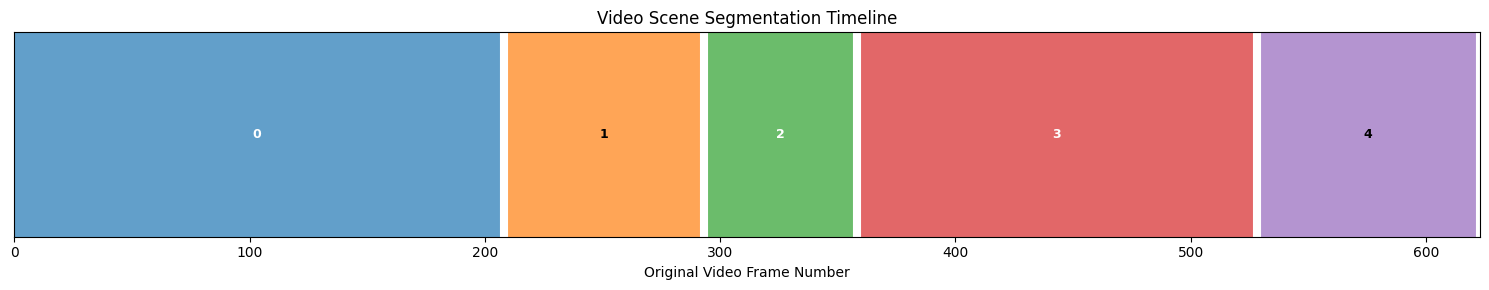


Scene Information (Scene ID, Original Start Frame, Original End Frame):
  Scene 0: Frames 0 - 205
  Scene 1: Frames 210 - 290
  Scene 2: Frames 295 - 355
  Scene 3: Frames 360 - 525
  Scene 4: Frames 530 - 620

Representative frames per scene:

--- Scene 0 (Frames 0-205) ---
  Displaying original frame: 0


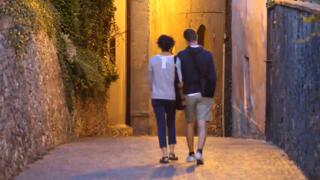

  Displaying original frame: 205


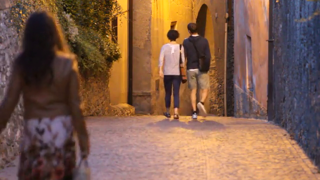


--- Scene 1 (Frames 210-290) ---
  Displaying original frame: 210


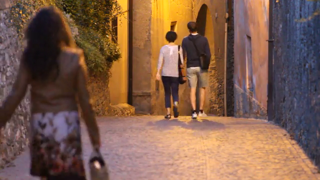

  Displaying original frame: 290


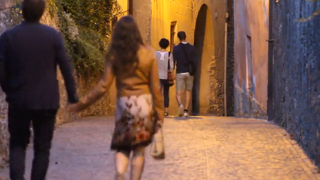


--- Scene 2 (Frames 295-355) ---
  Displaying original frame: 295


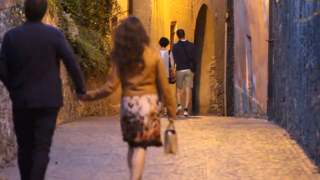

  Displaying original frame: 355


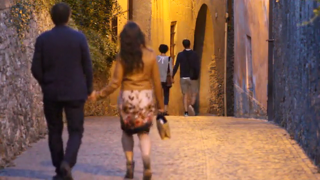


--- Scene 3 (Frames 360-525) ---
  Displaying original frame: 360


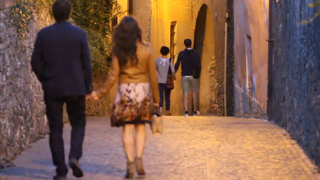

  Displaying original frame: 525


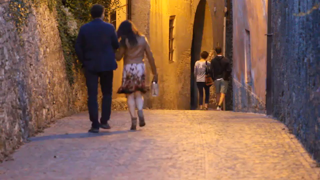


--- Scene 4 (Frames 530-620) ---
  Displaying original frame: 530


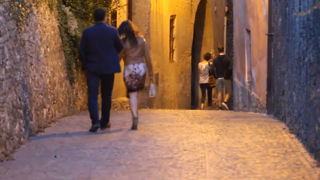

  Displaying original frame: 620


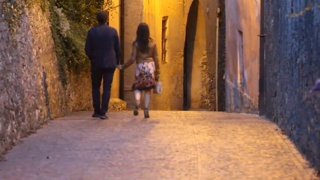

In [12]:

# ----- Jupyter Notebookのセルで以下を実行 -----
#
# 0. パラメータ設定
VIDEO_PATH = "/content/3974-176000794_tiny.mp4"  # ★★★ あなたの動画ファイルパスに置き換えてください ★★★
FRAME_SKIP_PROCESSING = 5  # Nフレームごとに特徴抽出 (1なら全フレーム)
BATCH_SIZE_FEATURES = 16 # 特徴抽出時のバッチサイズ
DETECTION_METHOD = "clustering" # "similarity" or "clustering"

# シーン検出のパラメータ
SIMILARITY_THRESHOLD = 0.75 # (similarity法用) 値が低いほど多くのシーンが検出される
NUM_SCENES_APPROX = None    # (clustering法用) Noneで自動推定。指定する場合は整数値 (例: 10)
MIN_SCENE_LENGTH_FEATURES = 5 # (clustering法用) 特徴抽出後のフレーム数での最小シーン長

# 可視化オプション
SHOW_REPRESENTATIVE_FRAMES = True
NUM_REPRESENTATIVE_FRAMES_PER_SCENE = 2

if not os.path.exists(VIDEO_PATH):
    print(f"Error: Video file not found at {VIDEO_PATH}")
else:
    # 1. Dino v2モデルのロード
    print("Loading Dino v2 model...")
    dino_model = load_dino_v2_model()

    if dino_model:
        # 2. 動画からフレームを抽出し、特徴を計算
        print(f"\nProcessing video: {VIDEO_PATH}...")
        frame_features, original_feature_frame_indices, extracted_frames_pil, total_original_frames = process_video(
            VIDEO_PATH,
            dino_model,
            batch_size=BATCH_SIZE_FEATURES,
            frame_skip=FRAME_SKIP_PROCESSING
        )

        if frame_features is not None and original_feature_frame_indices:
            num_feature_frames = len(frame_features)
            print(f"\nExtracted {num_feature_frames} features from {len(original_feature_frame_indices)} sampled frames (every {FRAME_SKIP_PROCESSING} original frames).")
            print(f"Original video has {total_original_frames} total frames.")

            # 3. シーン境界検出
            print(f"\nDetecting scene boundaries using {DETECTION_METHOD} method...")
            if DETECTION_METHOD == "similarity":
                scene_boundary_feature_indices = detect_scenes_by_similarity(frame_features, threshold=SIMILARITY_THRESHOLD)
            elif DETECTION_METHOD == "clustering":
                scene_boundary_feature_indices = detect_scenes_by_clustering(
                    frame_features,
                    num_scenes_approx=NUM_SCENES_APPROX,
                    min_scene_length_features=MIN_SCENE_LENGTH_FEATURES
                )
            else:
                print(f"Error: Unknown detection method {DETECTION_METHOD}")
                scene_boundary_feature_indices = [0] # フォールバック

            if not scene_boundary_feature_indices: # 検出されなかった場合
                 scene_boundary_feature_indices = [0] # ビデオ全体を1シーンとする

            print(f"Scene boundary indices (in terms of processed feature frames): {scene_boundary_feature_indices}")

            # 4. シーン割り当て情報の生成
            scene_info_orig_frames, feature_frame_scene_labels = generate_scene_assignments(
                original_feature_frame_indices,
                scene_boundary_feature_indices,
                num_feature_frames
            )

            # 5. シーン分類結果の可視化
            print("\nVisualizing scene timeline...")
            visualize_scene_timeline(scene_info_orig_frames, total_original_frames, original_feature_frame_indices, feature_frame_scene_labels)

            # 6. (オプション) 各シーンの代表フレームを表示
            if SHOW_REPRESENTATIVE_FRAMES and scene_info_orig_frames:
                display_representative_frames(VIDEO_PATH, scene_info_orig_frames, num_frames_per_scene=NUM_REPRESENTATIVE_FRAMES_PER_SCENE)

        else:
            print("Feature extraction failed.")
    else:
        print("DinoV2 model loading failed.")